In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [3]:
conn = sqlite3.connect('../AdventureWorks.db')

internet = pd.read_sql("""
    SELECT 
        s.SalesAmount,
        s.OrderQuantity,
        s.UnitPrice,
        s.DiscountAmount,
        s.TotalProductCost,
        s.TaxAmt,
        s.Freight,
        s.UnitPriceDiscountPct,
        s.OrderDateKey,
        s.SalesTerritoryKey,
        s.PromotionKey,
        'Internet' as Source
    FROM FactInternetSales s
""", conn)

reseller = pd.read_sql("""
    SELECT 
        s.SalesAmount,
        s.OrderQuantity,
        s.UnitPrice,
        s.DiscountAmount,
        s.TotalProductCost,
        s.TaxAmt,
        s.Freight,
        s.UnitPriceDiscountPct,
        s.OrderDateKey,
        s.SalesTerritoryKey,
        s.PromotionKey,
        'Reseller' as Source
    FROM FactResellerSales s
""", conn)

df = pd.concat([internet, reseller], ignore_index=True)
conn.close()
print(df.shape)
df.head()

(119218, 12)


,SalesAmount,OrderQuantity,UnitPrice,DiscountAmount,TotalProductCost,TaxAmt,Freight,UnitPriceDiscountPct,OrderDateKey,SalesTerritoryKey,PromotionKey,Source
0,3578.2700,1,3578.2700,0.0,2171.2942,286.2616,89.4568,0.0,20101229,6,1,Internet
1,3399.9900,1,3399.9900,0.0,1912.1544,271.9992,84.9998,0.0,20101229,7,1,Internet
2,3399.9900,1,3399.9900,0.0,1912.1544,271.9992,84.9998,0.0,20101229,1,1,Internet
3,699.0982,1,699.0982,0.0,413.1463,55.9279,17.4775,0.0,20101229,4,1,Internet
4,3399.9900,1,3399.9900,0.0,1912.1544,271.9992,84.9998,0.0,20101229,9,1,Internet


In [10]:
# Extract month and year from OrderDateKey (format: YYYYMMDD)
df['Year'] = df['OrderDateKey'].astype(str).str[:4].astype(int)
df['Month'] = df['OrderDateKey'].astype(str).str[4:6].astype(int)

# Encode Source column
df['IsInternet'] = (df['Source'] == 'Internet').astype(int)

# Drop original columns not needed for regression
df_model = df.drop(columns=[
    'OrderDateKey', 
    'Source',
    'TotalProductCost',  # derived from SalesAmount
    'TaxAmt',            # derived from SalesAmount
    'Freight'            # derived from SalesAmount
])

print(df_model.dtypes)
df_model.describe()

SalesAmount             float64
OrderQuantity             int64
UnitPrice               float64
DiscountAmount          float64
UnitPriceDiscountPct    float64
SalesTerritoryKey         int64
PromotionKey              int64
Year                      int64
Month                     int64
IsInternet                int64
dtype: object


,SalesAmount,OrderQuantity,UnitPrice,DiscountAmount,UnitPriceDiscountPct,SalesTerritoryKey,PromotionKey,Year,Month,IsInternet
count,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000
mean,900.473799,2.245106,466.116090,4.362494,0.002682,5.409854,1.158005,2012.591085,6.503213,0.506618
std,1687.844691,2.476633,755.770042,62.777211,0.023598,2.835529,1.188997,0.703747,3.518390,0.499958
min,1.374000,1.000000,1.328200,0.000000,0.000000,1.000000,1.000000,2010.000000,1.000000,0.000000
25%,24.990000,1.000000,21.490000,0.000000,0.000000,4.000000,1.000000,2012.000000,3.000000,0.000000
50%,127.800000,1.000000,49.990000,0.000000,0.000000,6.000000,1.000000,2013.000000,7.000000,1.000000
75%,1120.490000,3.000000,600.262500,0.000000,0.000000,8.000000,1.000000,2013.000000,10.000000,1.000000
max,27893.619000,44.000000,3578.270000,4005.237600,0.400000,10.000000,16.000000,2014.000000,12.000000,1.000000


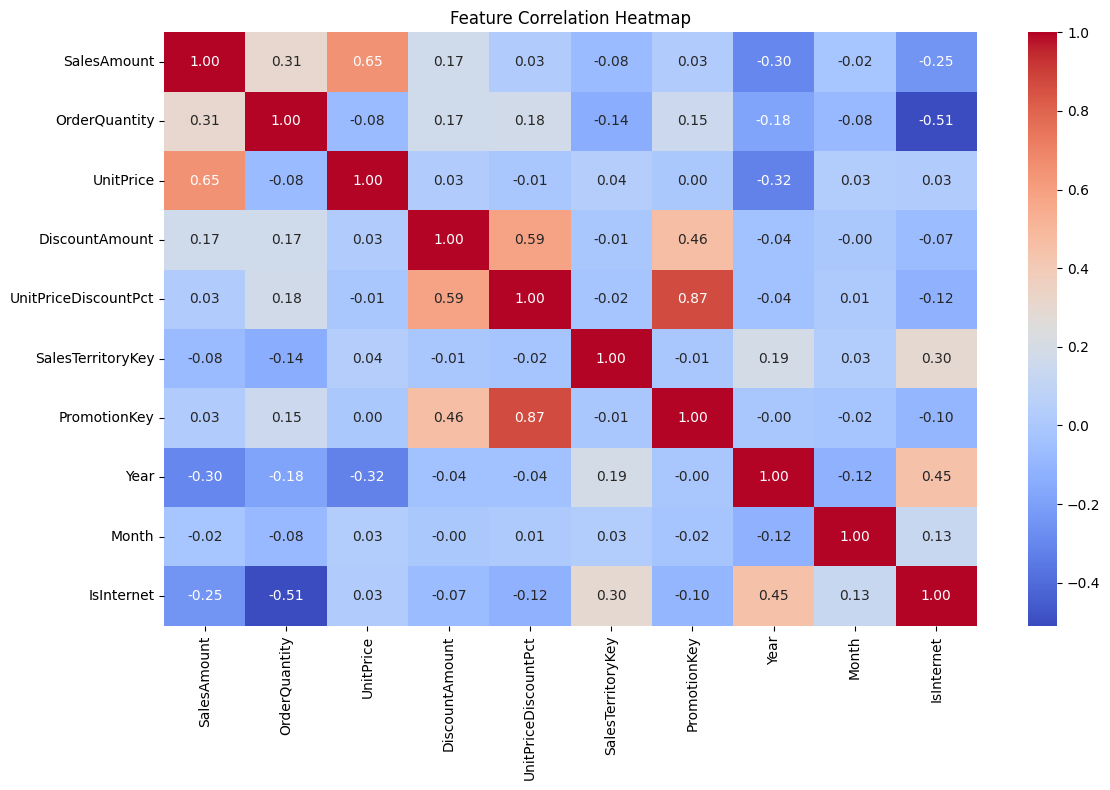

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_model.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [12]:
def run_regression(df, target):
    X = df.drop(columns=['SalesAmount', 'OrderQuantity'])
    y = df[target]
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    # Sklearn model
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*40}")
    print(f"Target: {target}")
    print(f"R² Score:  {r2_score(y_test, y_pred):.4f}")
    print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    
    # Statsmodels for p-values
    X_sm = sm.add_constant(X_scaled)
    sm_model = sm.OLS(y, X_sm).fit()
    print(sm_model.summary())
    
    # Feature importance plot
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_
    }).sort_values('Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
    plt.title(f'Feature Coefficients — {target}')
    plt.tight_layout()
    plt.savefig(f'regression_{target}.png')
    plt.show()
    
    return model, scaler


Target: SalesAmount
R² Score:  0.5233
RMSE:      1179.4543
                            OLS Regression Results                            
Dep. Variable:            SalesAmount   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                 1.615e+04
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        20:13:55   Log-Likelihood:            -1.0113e+06
No. Observations:              119218   AIC:                         2.023e+06
Df Residuals:                  119209   BIC:                         2.023e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

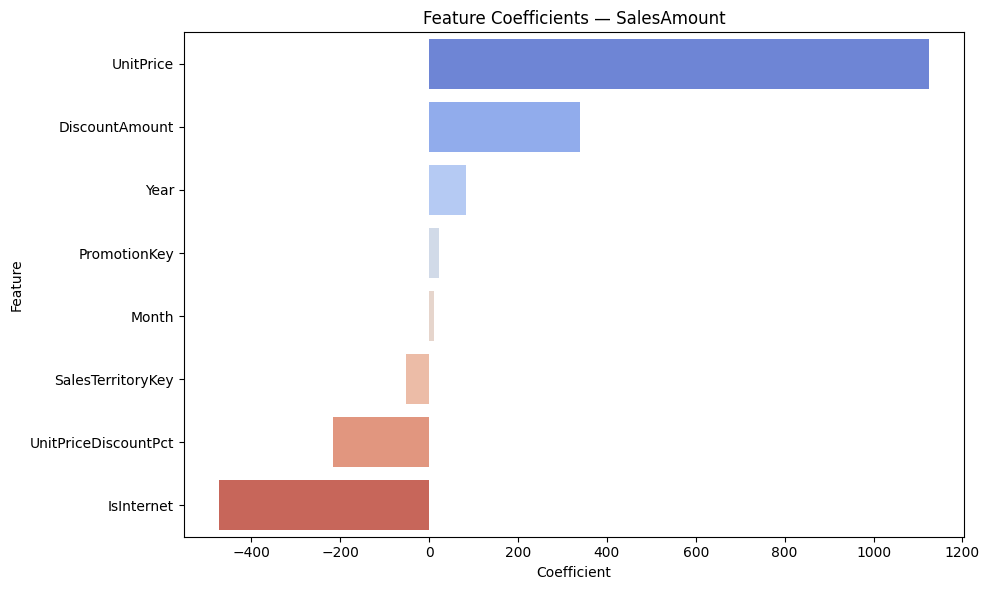


Target: OrderQuantity
R² Score:  0.2859
RMSE:      2.1230
                            OLS Regression Results                            
Dep. Variable:          OrderQuantity   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     5957.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        20:13:55   Log-Likelihood:            -2.5723e+05
No. Observations:              119218   AIC:                         5.145e+05
Df Residuals:                  119209   BIC:                         5.146e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

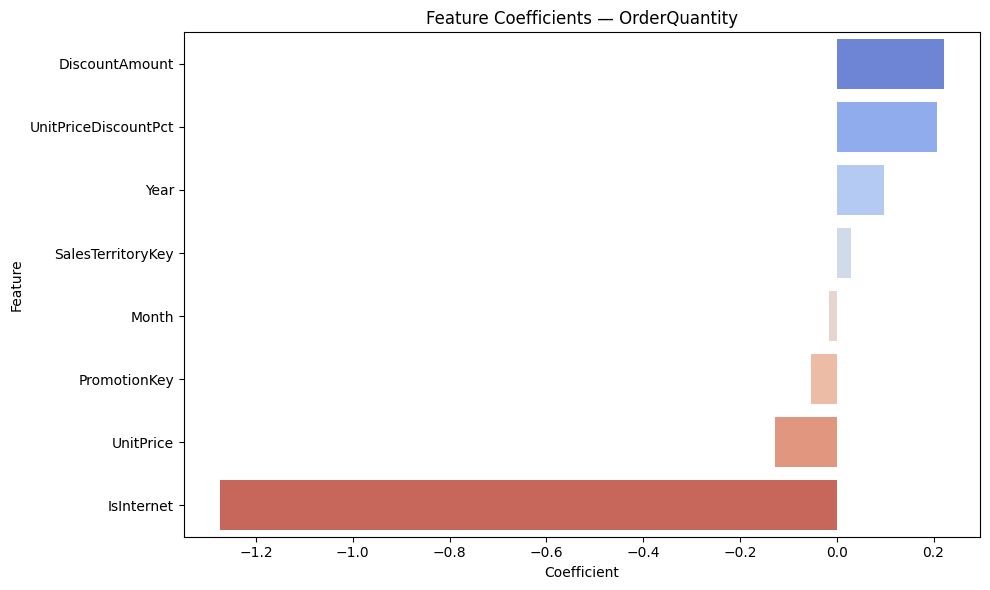

In [13]:
model_sales, scaler_sales = run_regression(df_model, 'SalesAmount')
model_qty, scaler_qty = run_regression(df_model, 'OrderQuantity')


Random Forest — Target: SalesAmount
R² Score:  0.7356
RMSE:      878.3362

Feature Importances:
                Feature  Importance
0             UnitPrice    0.746535
7            IsInternet    0.077256
6                 Month    0.036603
1        DiscountAmount    0.035293
3     SalesTerritoryKey    0.034551
4          PromotionKey    0.028621
2  UnitPriceDiscountPct    0.020970
5                  Year    0.020171


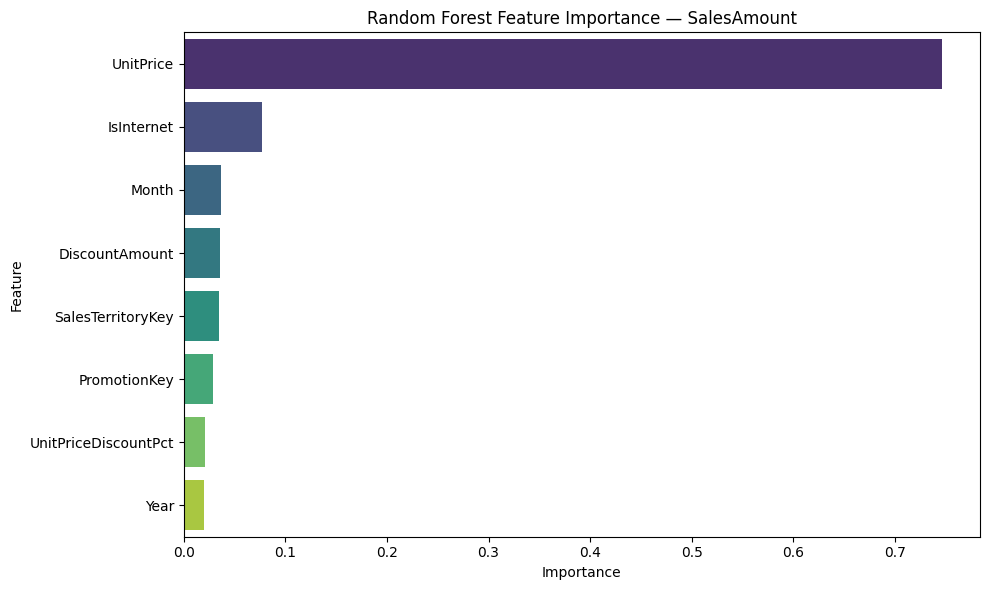


Random Forest — Target: OrderQuantity
R² Score:  0.6931
RMSE:      1.3918

Feature Importances:
                Feature  Importance
7            IsInternet    0.228654
2  UnitPriceDiscountPct    0.213926
1        DiscountAmount    0.193615
4          PromotionKey    0.179001
0             UnitPrice    0.085183
6                 Month    0.046267
3     SalesTerritoryKey    0.044596
5                  Year    0.008759


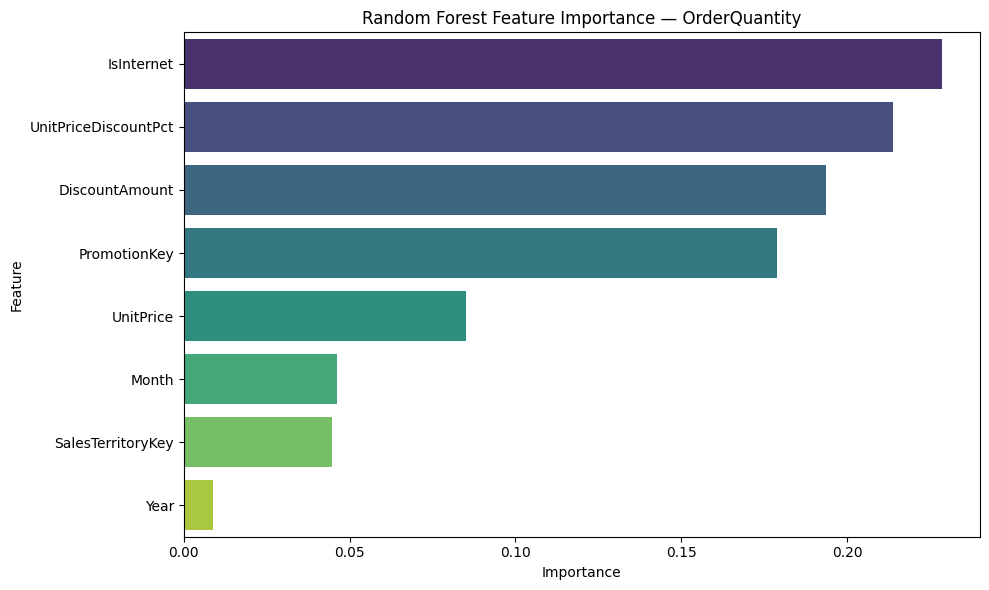

In [14]:
from sklearn.ensemble import RandomForestRegressor

def run_random_forest(df, target):
    X = df.drop(columns=['SalesAmount', 'OrderQuantity'])
    y = df[target]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\n{'='*40}")
    print(f"Random Forest — Target: {target}")
    print(f"R² Score:  {r2:.4f}")
    print(f"RMSE:      {rmse:.4f}")
    
    # Feature importance
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importances:")
    print(importance_df)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Random Forest Feature Importance — {target}')
    plt.tight_layout()
    plt.savefig(f'rf_importance_{target}.png')
    plt.show()
    
    return rf, importance_df

rf_sales, imp_sales = run_random_forest(df_model, 'SalesAmount')
rf_qty, imp_qty = run_random_forest(df_model, 'OrderQuantity')

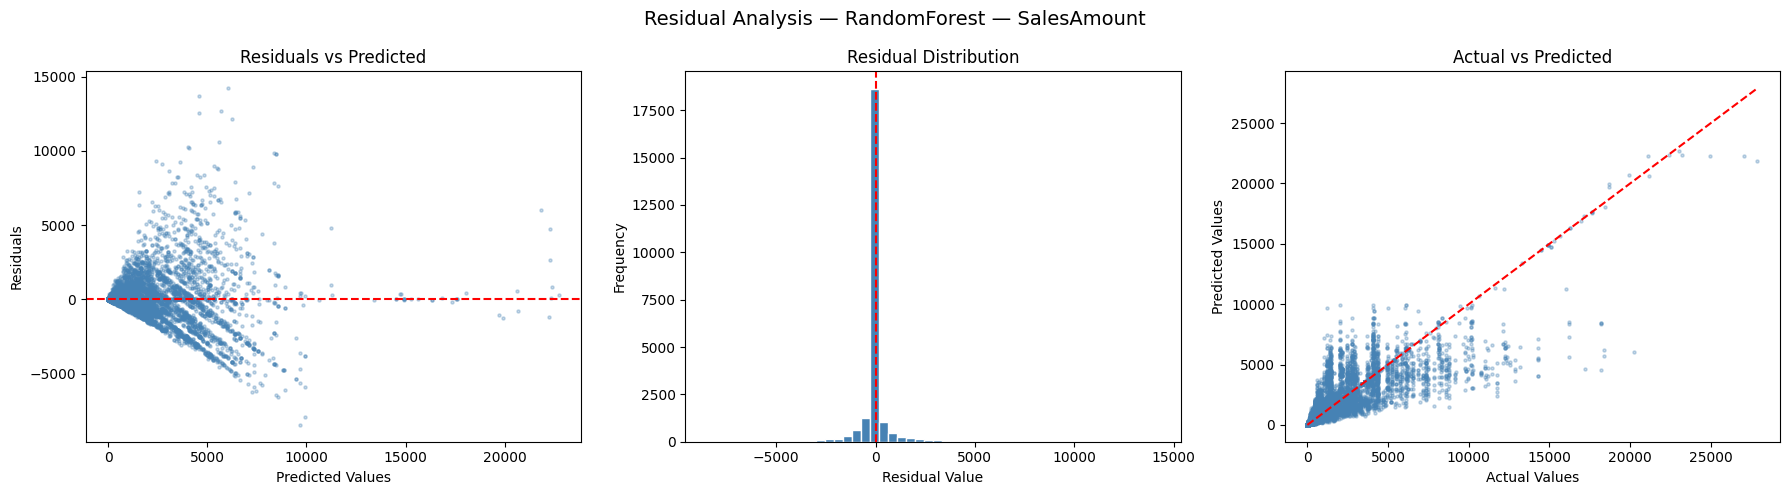


Residual Summary — SalesAmount
Mean Residual:    -5.7692
Std Residual:     878.3357
Max Overprediction:  -8440.1227
Max Underprediction: 14215.0317


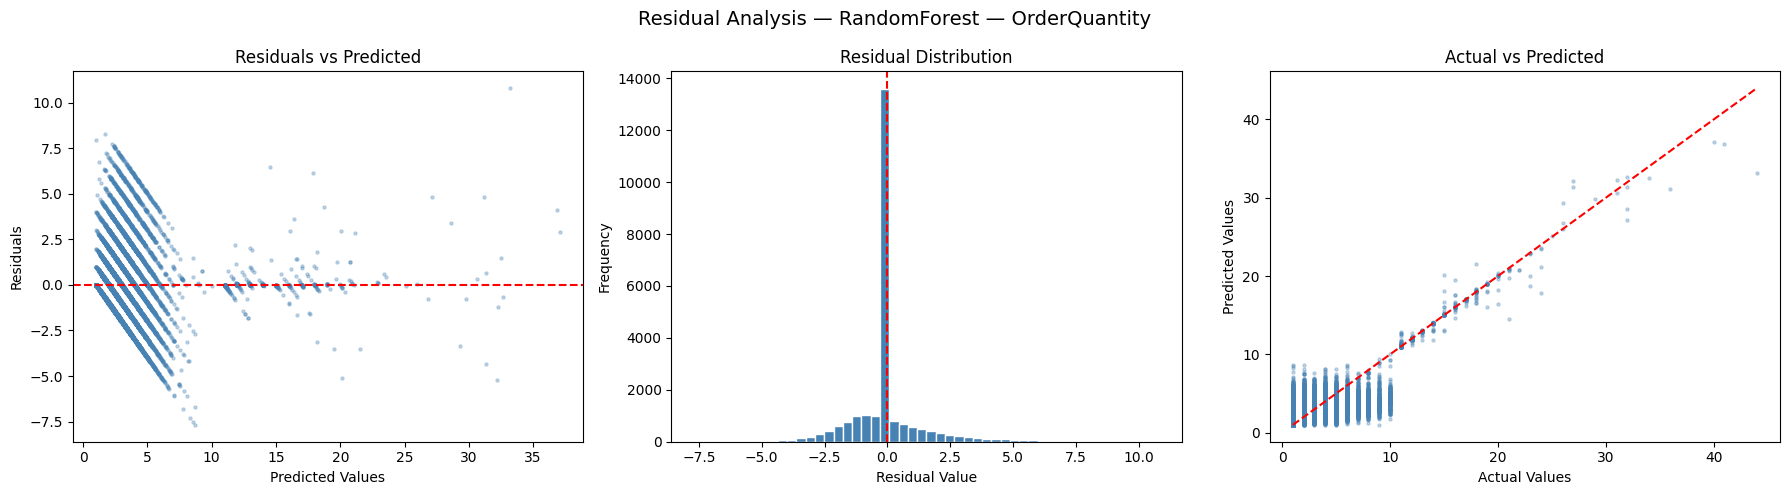


Residual Summary — OrderQuantity
Mean Residual:    0.0000
Std Residual:     1.3918
Max Overprediction:  -7.6802
Max Underprediction: 10.7900


In [15]:
def plot_residuals(df, target, model, model_name='Model'):
    X = df.drop(columns=['SalesAmount', 'OrderQuantity'])
    y = df[target]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Residual Analysis — {model_name} — {target}', fontsize=14)
    
    # Plot 1 - Residuals vs Predicted
    axes[0].scatter(y_pred, residuals, alpha=0.3, color='steelblue', s=5)
    axes[0].axhline(y=0, color='red', linestyle='--')
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Predicted')
    
    # Plot 2 - Residual Distribution
    axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
    axes[1].axvline(x=0, color='red', linestyle='--')
    axes[1].set_xlabel('Residual Value')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Residual Distribution')
    
    # Plot 3 - Actual vs Predicted
    axes[2].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=5)
    axes[2].plot([y_test.min(), y_test.max()], 
                 [y_test.min(), y_test.max()], 
                 color='red', linestyle='--')
    axes[2].set_xlabel('Actual Values')
    axes[2].set_ylabel('Predicted Values')
    axes[2].set_title('Actual vs Predicted')
    
    plt.tight_layout()
    plt.savefig(f'residuals_{model_name}_{target}.png')
    plt.show()
    
    # Summary stats
    print(f"\nResidual Summary — {target}")
    print(f"Mean Residual:    {residuals.mean():.4f}")
    print(f"Std Residual:     {residuals.std():.4f}")
    print(f"Max Overprediction:  {residuals.min():.4f}")
    print(f"Max Underprediction: {residuals.max():.4f}")

# Run for both targets using Random Forest
plot_residuals(df_model, 'SalesAmount', rf_sales, 'RandomForest')
plot_residuals(df_model, 'OrderQuantity', rf_qty, 'RandomForest')

OrderQuantity Distribution:
OrderQuantity
1     74405
2     13712
3      9737
4      7243
5      4245
6      3187
7      1675
8      1476
9       810
10      744
11      375
12      446
13      221
14      248
15      116
16      130
17       90
18       98
19       52
20       44
21       30
22       12
23       22
24       19
25       17
26       15
27        9
28        6
29        3
30        1
31        4
32        7
33        6
34        3
35        2
36        2
38        1
39        1
40        2
41        1
44        1
Name: count, dtype: int64

Random Forest Classifier — OrderQuantity
Accuracy: 0.6392

Classification Report:
              precision    recall  f1-score   support

           1       0.84      0.90      0.87     14990
           2       0.27      0.32      0.29      2721
           3       0.19      0.18      0.18      1901
           4       0.18      0.16      0.17      1454
           5       0.15      0.09      0.11       839
           6       0.09      0.0

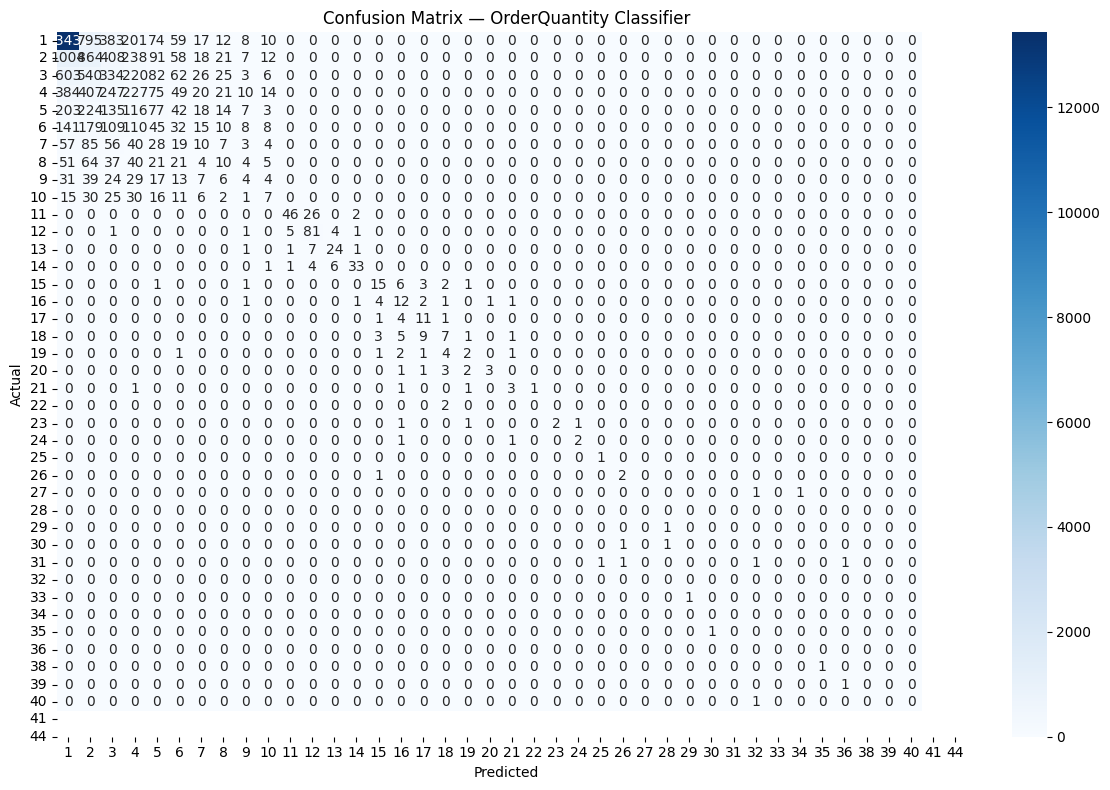


Feature Importances:
                Feature  Importance
7            IsInternet    0.389270
0             UnitPrice    0.273190
3     SalesTerritoryKey    0.100724
6                 Month    0.098359
5                  Year    0.069995
1        DiscountAmount    0.049010
2  UnitPriceDiscountPct    0.011993
4          PromotionKey    0.007459


In [ ]:
# 9 code block
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def run_quantity_classifier(df):
    X = df.drop(columns=['SalesAmount', 'OrderQuantity'])
    y = df['OrderQuantity']
    
    # Check distribution of quantity values
    print("OrderQuantity Distribution:")
    print(y.value_counts().sort_index())
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*40}")
    print(f"Random Forest Classifier — OrderQuantity")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y.unique()),
                yticklabels=sorted(y.unique()))
    plt.title('Confusion Matrix — OrderQuantity Classifier')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig('confusion_matrix_orderquantity.png')
    plt.show()
    
    # Feature importance
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': clf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importances:")
    print(importance_df)
    
    return clf, scaler

clf_qty, scaler_clf = run_quantity_classifier(df_model)

Bucketed OrderQuantity Distribution:
OrderQuantity
Single          74405
Small_Medium    42829
Large            1820
Bulk              164
Name: count, dtype: int64

Bucketed Classifier — OrderQuantity
Accuracy: 0.8731

Classification Report:
              precision    recall  f1-score   support

        Bulk       0.96      0.75      0.84        36
       Large       0.98      0.99      0.98       363
      Single       0.94      0.85      0.89     14990
Small_Medium       0.77      0.91      0.84      8455

    accuracy                           0.87     23844
   macro avg       0.91      0.87      0.89     23844
weighted avg       0.88      0.87      0.87     23844



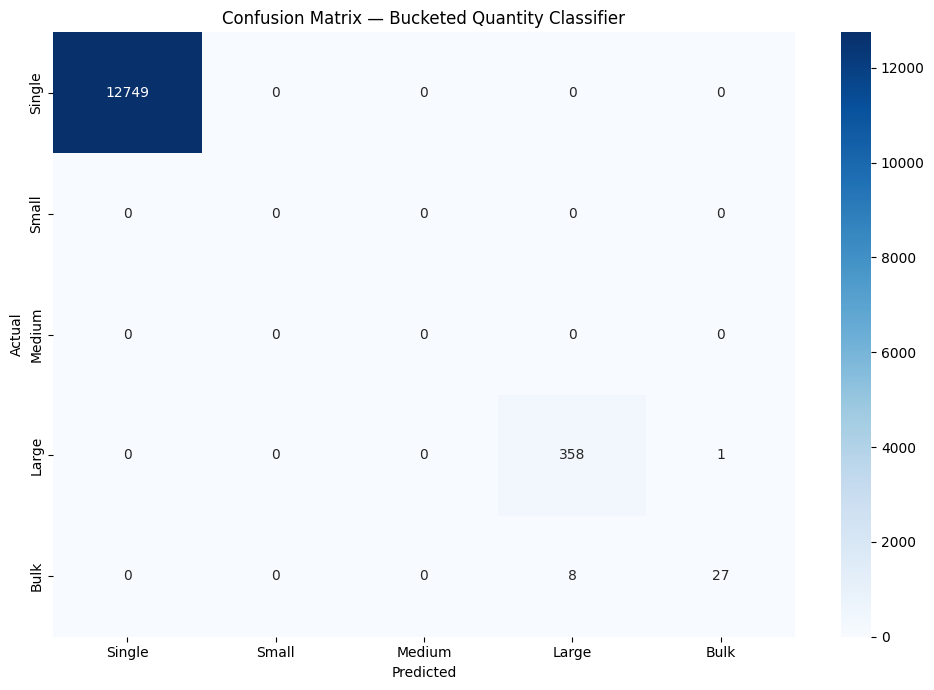


Feature Importances:
                Feature  Importance
7            IsInternet    0.549922
0             UnitPrice    0.173570
5                  Year    0.094591
3     SalesTerritoryKey    0.061583
6                 Month    0.041310
1        DiscountAmount    0.032807
2  UnitPriceDiscountPct    0.028172
4          PromotionKey    0.018043


In [ ]:
#10 block
def bucket_quantity(q):
    if q == 1:
        return 'Single'
    elif q <= 10:
        return 'Small_Medium'
    elif q <= 20:
        return 'Large'
    else:
        return 'Bulk'

def run_bucketed_classifier(df):
    X = df.drop(columns=['SalesAmount', 'OrderQuantity'])
    y = df['OrderQuantity'].apply(bucket_quantity)
    
    # Check bucketed distribution
    print("Bucketed OrderQuantity Distribution:")
    print(y.value_counts())
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*40}")
    print(f"Bucketed Classifier — OrderQuantity")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    labels = ['Single', 'Small', 'Medium', 'Large', 'Bulk']
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title('Confusion Matrix — Bucketed Quantity Classifier')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig('confusion_matrix_bucketed.png')
    plt.show()
    
    # Feature importance
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': clf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importances:")
    print(importance_df)
    
    return clf, scaler, importance_df

clf_bucketed, scaler_bucketed, imp_bucketed = run_bucketed_classifier(df_model)

In [29]:
#11
def engineer_advanced_features(df):
    df_advanced = df.copy()
    
    # Revenue per Unit
    df_advanced['RevenuePerUnit'] = (
        df_advanced['SalesAmount'] / df_advanced['OrderQuantity']
    ).replace([np.inf, -np.inf], 0).fillna(0)
    
    # Discount Flag
    df_advanced['DiscountFlag'] = (
        df_advanced['DiscountAmount'] > 0
    ).astype(int)
    
    # Quarter
    df_advanced['Quarter'] = pd.cut(
        df_advanced['Month'],
        bins=[0, 3, 6, 9, 12],
        labels=[1, 2, 3, 4]
    ).astype(int)
    
    # High Value Flag — orders above mean sales amount
    mean_sales = df_advanced['SalesAmount'].mean()
    df_advanced['HighValueFlag'] = (
        df_advanced['SalesAmount'] > mean_sales
    ).astype(int)
    
    # Discount Intensity — binned discount percentage
    df_advanced['DiscountIntensity'] = pd.cut(
        df_advanced['UnitPriceDiscountPct'],
        bins=[-0.01, 0, 0.1, 0.2, 0.4, 1.0],
        labels=[0, 1, 2, 3, 4]
    ).astype(int)
    
    print("Advanced Features Added:")
    print(df_advanced.dtypes)
    print(f"\nShape: {df_advanced.shape}")
    print(f"\nSample:")
    print(df_advanced[['RevenuePerUnit', 'DiscountFlag', 
                        'Quarter', 'HighValueFlag', 
                        'DiscountIntensity']].head())
    
    return df_advanced

df_advanced = engineer_advanced_features(df_model)

Advanced Features Added:
SalesAmount             float64
OrderQuantity             int64
UnitPrice               float64
DiscountAmount          float64
UnitPriceDiscountPct    float64
SalesTerritoryKey         int64
PromotionKey              int64
Year                      int64
Month                     int64
IsInternet                int64
RevenuePerUnit          float64
DiscountFlag              int64
Quarter                   int64
HighValueFlag             int64
DiscountIntensity         int64
dtype: object

Shape: (119218, 15)

Sample:
   RevenuePerUnit  DiscountFlag  Quarter  HighValueFlag  DiscountIntensity
0       3578.2700             0        4              1                  0
1       3399.9900             0        4              1                  0
2       3399.9900             0        4              1                  0
3        699.0982             0        4              0                  0
4       3399.9900             0        4              1                  0


=== Random Forest SalesAmount (leakage fixed) ===

Random Forest — Target: SalesAmount
R² Score:  0.7353
RMSE:      878.8614

Feature Importances:
                 Feature  Importance
0              UnitPrice    0.671828
7             IsInternet    0.077025
8         RevenuePerUnit    0.075537
3      SalesTerritoryKey    0.034551
6                  Month    0.030296
1         DiscountAmount    0.022135
9           DiscountFlag    0.020514
5                   Year    0.020391
4           PromotionKey    0.014996
11     DiscountIntensity    0.013525
2   UnitPriceDiscountPct    0.012924
10               Quarter    0.006279


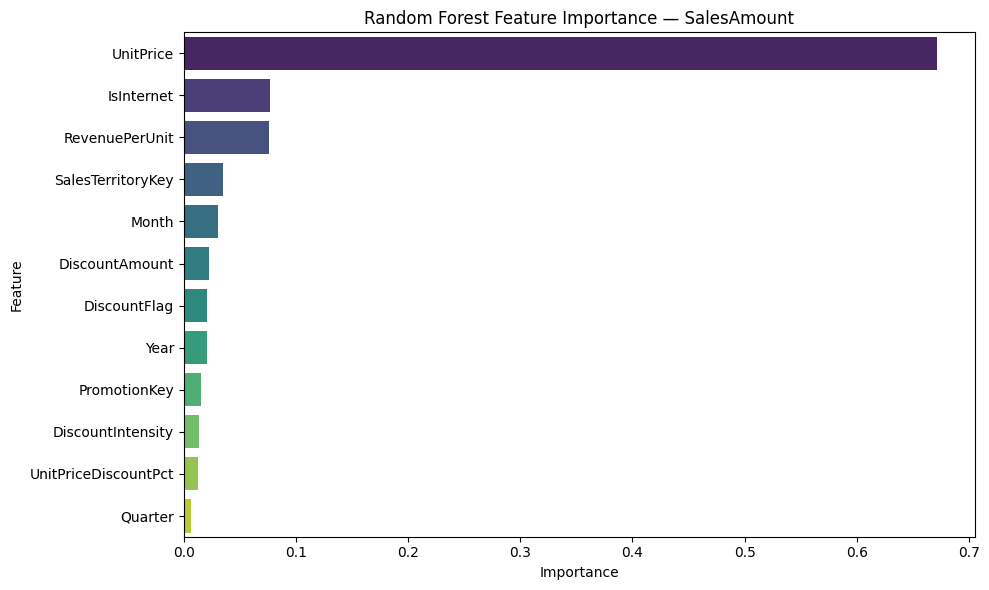


=== Bucketed Classifier with Advanced Features ===

Bucketed Classifier Accuracy: 0.9051
              precision    recall  f1-score   support

        Bulk       0.96      0.75      0.84        36
       Large       0.98      0.99      0.98       363
      Single       0.95      0.90      0.92     14990
Small_Medium       0.84      0.91      0.87      8455

    accuracy                           0.91     23844
   macro avg       0.93      0.89      0.91     23844
weighted avg       0.91      0.91      0.91     23844



In [30]:
#[12] Fix leakage - drop HighValueFlag for SalesAmount regression
df_sales_clean = df_advanced.drop(columns=['HighValueFlag'])
print("=== Random Forest SalesAmount (leakage fixed) ===")
rf_sales_adv, imp_sales_adv = run_random_forest(df_sales_clean, 'SalesAmount')

# Bucketed Classifier with advanced features
print("\n=== Bucketed Classifier with Advanced Features ===")
df_advanced_model = df_advanced.copy()
df_advanced_model['OrderQuantityBucket'] = (
    df_advanced_model['OrderQuantity'].apply(bucket_quantity)
)
df_advanced_model = df_advanced_model.drop(columns=['OrderQuantity'])

X = df_advanced_model.drop(columns=['SalesAmount', 'OrderQuantityBucket'])
y_cls = df_advanced_model['OrderQuantityBucket']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cls, test_size=0.2, random_state=42
)

clf_adv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_adv.fit(X_train, y_train)
y_pred = clf_adv.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nBucketed Classifier Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

In [ ]:
#13
from sklearn.model_selection import cross_val_score, KFold

def run_cross_validation(df_advanced):
    # Use same setup as combined model — drop leakage columns
    df_cv = df_advanced.drop(columns=['HighValueFlag', 'RevenuePerUnit'])
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # SalesAmount Regression
    X_reg = df_cv.drop(columns=['SalesAmount', 'OrderQuantity'])
    y_reg = df_cv['SalesAmount']
    
    scaler = StandardScaler()
    X_reg_scaled = scaler.fit_transform(X_reg)
    
    rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    cv_r2 = cross_val_score(rf_reg, X_reg_scaled, y_reg, cv=kf, scoring='r2')
    cv_rmse = cross_val_score(rf_reg, X_reg_scaled, y_reg, cv=kf, 
                               scoring='neg_root_mean_squared_error')
    
    print("="*40)
    print("Cross Validation — SalesAmount Regression")
    print("="*40)
    print(f"R2 per fold:    {[round(x, 4) for x in cv_r2]}")
    print(f"R2 Mean:        {cv_r2.mean():.4f}")
    print(f"R2 Std:         {cv_r2.std():.4f}")
    print(f"RMSE per fold:  {[round(abs(x), 2) for x in cv_rmse]}")
    print(f"RMSE Mean:      {abs(cv_rmse.mean()):.4f}")
    print(f"RMSE Std:       {abs(cv_rmse.std()):.4f}")
    
    # Bucketed Classifier
    df_cls = df_cv.copy()
    df_cls['OrderQuantityBucket'] = df_cls['OrderQuantity'].apply(bucket_quantity)
    df_cls = df_cls.drop(columns=['OrderQuantity'])
    
    X_cls = df_cls.drop(columns=['SalesAmount', 'OrderQuantityBucket'])
    y_cls = df_cls['OrderQuantityBucket']
    
    scaler_cls = StandardScaler()
    X_cls_scaled = scaler_cls.fit_transform(X_cls)
    
    rf_cls = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    cv_acc = cross_val_score(rf_cls, X_cls_scaled, y_cls, cv=kf, scoring='accuracy')
    cv_f1 = cross_val_score(rf_cls, X_cls_scaled, y_cls, cv=kf, scoring='f1_weighted')
    
    print("\n" + "="*40)
    print("Cross Validation — Bucketed Classifier")
    print("="*40)
    print(f"Accuracy per fold:  {[round(x, 4) for x in cv_acc]}")
    print(f"Accuracy Mean:      {cv_acc.mean():.4f}")
    print(f"Accuracy Std:       {cv_acc.std():.4f}")
    print(f"F1 per fold:        {[round(x, 4) for x in cv_f1]}")
    print(f"F1 Mean:            {cv_f1.mean():.4f}")
    print(f"F1 Std:             {cv_f1.std():.4f}")

run_cross_validation(df_advanced)

Cross Validation — SalesAmount Regression
R2 per fold:    [np.float64(0.7356), np.float64(0.7077), np.float64(0.73), np.float64(0.7096), np.float64(0.7164)]
R2 Mean:        0.7199
R2 Std:         0.0111
RMSE per fold:  [np.float64(878.4), np.float64(910.11), np.float64(873.25), np.float64(895.11), np.float64(908.18)]
RMSE Mean:      893.0128
RMSE Std:       15.0379

Cross Validation — Bucketed Classifier
Accuracy per fold:  [np.float64(0.8723), np.float64(0.8713), np.float64(0.872), np.float64(0.8673), np.float64(0.8722)]
Accuracy Mean:      0.8710
Accuracy Std:       0.0019
F1 per fold:        [np.float64(0.874), np.float64(0.873), np.float64(0.8737), np.float64(0.869), np.float64(0.874)]
F1 Mean:            0.8727
F1 Std:             0.0019
